# Similarity Study Figure Final

Creates one 1x7 figure: the same Spearman correlation bar chart as `similarity_study_figure.ipynb`, followed by six square scatter plots ordered from highest to lowest Pearson correlation.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble": "",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
})

print("Matplotlib external LaTeX rendering: disabled; using Times/STIX fallback")


Matplotlib external LaTeX rendering: disabled; using Times/STIX fallback


In [22]:
# -----------------------------
# 1. Load complete pairwise datasets from multiple AOIs
# -----------------------------

cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent]
root_dir = next(
    (path for path in root_candidates if (path / "eval" / "superpoint_matching").exists()),
    Path("/home/roger/sat-bundleadjust_github"),
)

aoi_ids = [
    "OMA_042", "OMA_132", "OMA_134", "OMA_144", "OMA_163", "OMA_172", "OMA_176", "OMA_203", "OMA_211", "OMA_230",
    "OMA_244", "OMA_247", "OMA_248", "OMA_251", "OMA_258", "OMA_269", "OMA_278", "OMA_281", "OMA_287", "OMA_315",
    "OMA_329", "OMA_331", "OMA_342", "OMA_353", "OMA_355", "OMA_367", "OMA_381", "OMA_383", "OMA_389", "OMA_391",
]

downsampled = False
suffix = "" if downsampled else "_wo_downsample"
csv_paths = [
    root_dir / "eval" / "superpoint_matching" / aoi_id / f"pairwise_image_similarities{suffix}.csv"
    for aoi_id in aoi_ids
]

similarity_cols = [
    "ssim",
    "dinov2",
    "dinov3_sat",
    "clip_rn50",
    "clip_vit_b32",
    "clip_vit_l14",
]

pretty_metric_names = {
    "ssim": "SSIM",
    "dinov2": "DINOv2",
    "dinov3_sat": "DINOv3 SAT",
    "clip_rn50": "CLIP RN50",
    "clip_vit_b32": "CLIP ViT-B/32",
    "clip_vit_l14": "CLIP ViT-L/14",
}

required_cols = [
    "image_1_index",
    "image_2_index",
    "image_1_basename",
    "image_2_basename",
    "superpoint_lightglue_num_matches",
] + similarity_cols

dfs = []

for aoi_id, csv_path in zip(aoi_ids, csv_paths):
    if not csv_path.exists():
        print(f"WARNING: CSV not found for AOI '{aoi_id}': {csv_path}")
        continue

    aoi_df = pd.read_csv(csv_path)
    missing_cols = [col for col in required_cols if col not in aoi_df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing expected columns for AOI '{aoi_id}' in {csv_path}: {missing_cols}"
        )

    aoi_df.insert(0, "aoi_id", aoi_id)
    aoi_df = aoi_df.rename(columns={"superpoint_lightglue_num_matches": "sift_matches"})
    aoi_df["pair_key"] = (
        aoi_df["aoi_id"].astype(str)
        + "__"
        + aoi_df["image_1_index"].astype(str)
        + "_"
        + aoi_df["image_2_index"].astype(str)
    )
    dfs.append(aoi_df)

if not dfs:
    raise RuntimeError("No AOI CSV files were loaded. Check aoi_ids and root_dir.")

df = pd.concat(dfs, ignore_index=True)

if "pair_id" not in df.columns:
    df.insert(0, "pair_id", np.arange(len(df)))

metrics = similarity_cols
target_col = "sift_matches"

numeric_cols = ["image_1_index", "image_2_index", target_col] + metrics
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep raw values available for inspection.
df_raw = df.copy()

valid_similarity_mask = np.ones(len(df), dtype=bool)
for col in metrics:
    valid_similarity_mask &= df[col].notna() & df[col].between(0, 1)

df_valid = df.loc[valid_similarity_mask].copy()

# Ordinary min-max normalize descriptors in place, matching similarity_study_figure.ipynb.
for col in metrics:
    valid = df[col].dropna()
    lo = valid.min()
    hi = valid.max()

    if len(valid) == 0 or pd.isna(lo) or pd.isna(hi) or hi == lo:
        print(f"WARNING: cannot min-max normalize '{col}' because range is invalid: min={lo}, max={hi}")
        df[col] = np.nan
        continue

    df[col] = (df[col] - lo) / (hi - lo)
    print(
        f"{col}: raw min={lo:.4f}, raw max={hi:.4f}, "
        f"normalized min={df[col].min(skipna=True):.4f}, "
        f"normalized max={df[col].max(skipna=True):.4f}"
    )

print()
print(f"Loaded {len(df)} image pairs from {df['aoi_id'].nunique()} AOIs")
print(f"Rows with valid raw similarities: {len(df_valid)} / {len(df)}")
print(f"Pairs with nonzero matches: {int((df[target_col] > 0).sum())} / {len(df)}")
print(f"Total matches: {int(df[target_col].fillna(0).sum())}")

df.head()


ssim: raw min=0.0892, raw max=0.7126, normalized min=0.0000, normalized max=1.0000
dinov2: raw min=0.6964, raw max=0.9953, normalized min=0.0000, normalized max=1.0000
dinov3_sat: raw min=0.5884, raw max=0.9912, normalized min=0.0000, normalized max=1.0000
clip_rn50: raw min=0.7641, raw max=0.9959, normalized min=0.0000, normalized max=1.0000
clip_vit_b32: raw min=0.8272, raw max=0.9972, normalized min=0.0000, normalized max=1.0000
clip_vit_l14: raw min=0.8559, raw max=0.9969, normalized min=0.0000, normalized max=1.0000

Loaded 24258 image pairs from 30 AOIs
Rows with valid raw similarities: 24258 / 24258
Pairs with nonzero matches: 24253 / 24258
Total matches: 4967460


,pair_id,aoi_id,image_1_index,image_2_index,image_1_basename,image_2_basename,sift_matches,ssim,dinov2,dinov3_sat,clip_rn50,clip_vit_b32,clip_vit_l14,pair_key
0,0,OMA_042,0,1,OMA_042_001_RGB.tif,OMA_042_002_RGB.tif,221,0.234384,0.969254,0.649248,0.961333,0.933482,0.862550,OMA_042__0_1
1,1,OMA_042,0,2,OMA_042_001_RGB.tif,OMA_042_003_RGB.tif,253,0.265824,0.890490,0.567241,0.914199,0.907182,0.873651,OMA_042__0_2
2,2,OMA_042,0,3,OMA_042_001_RGB.tif,OMA_042_004_RGB.tif,334,0.173916,0.922163,0.737725,0.960563,0.845841,0.928512,OMA_042__0_3
3,3,OMA_042,0,4,OMA_042_001_RGB.tif,OMA_042_006_RGB.tif,204,0.187882,0.902478,0.506861,0.950813,0.933353,0.925009,OMA_042__0_4
4,4,OMA_042,0,5,OMA_042_001_RGB.tif,OMA_042_007_RGB.tif,683,0.190570,0.896119,0.421130,0.909670,0.965349,0.884981,OMA_042__0_5


In [23]:
# -----------------------------
# 2. Correlate normalized similarity metrics with SuperPoint+LightGlue match counts
# -----------------------------

rows = []

for metric in metrics:
    valid = df[[metric, target_col]].copy()
    valid[metric] = pd.to_numeric(valid[metric], errors="coerce")
    valid[target_col] = pd.to_numeric(valid[target_col], errors="coerce")
    valid = valid.dropna()
    valid = valid[valid[metric].between(0, 1)]

    if len(valid) < 2:
        pearson_r = np.nan
        spearman_r = np.nan
        reason = "fewer than 2 valid rows"
    elif valid[metric].nunique() < 2:
        pearson_r = np.nan
        spearman_r = np.nan
        reason = "metric is constant"
    elif valid[target_col].nunique() < 2:
        pearson_r = np.nan
        spearman_r = np.nan
        reason = "match count is constant"
    else:
        pearson_r, _ = pearsonr(valid[metric], valid[target_col])
        spearman_r, _ = spearmanr(valid[metric], valid[target_col])
        reason = "ok"

    rows.append({
        "metric": metric,
        "metric_label": pretty_metric_names.get(metric, metric),
        "pearson": pearson_r,
        "spearman": spearman_r,
        "n_pairs": len(valid),
        "metric_min": valid[metric].min() if len(valid) else np.nan,
        "metric_max": valid[metric].max() if len(valid) else np.nan,
        "target_nonzero": int((valid[target_col] > 0).sum()) if len(valid) else 0,
        "reason": reason,
    })

# Keep the table order consistent with similarity_study_figure.ipynb.
corr_df = pd.DataFrame(rows).sort_values(
    "spearman",
    ascending=False,
    na_position="last",
).reset_index(drop=True)

pearson_ordered_metrics = corr_df.sort_values(
    "pearson",
    ascending=False,
    na_position="last",
)["metric"].tolist()
corr_df


,metric,metric_label,pearson,spearman,n_pairs,metric_min,metric_max,target_nonzero,reason
0,dinov2,DINOv2,0.495679,0.716340,24258,0.0,1.0,24253,ok
1,clip_rn50,CLIP RN50,0.464451,0.693885,24258,0.0,1.0,24253,ok
2,clip_vit_l14,CLIP ViT-L/14,0.510930,0.689321,24258,0.0,1.0,24253,ok
3,clip_vit_b32,CLIP ViT-B/32,0.440129,0.642227,24258,0.0,1.0,24253,ok
4,dinov3_sat,DINOv3 SAT,0.490864,0.590225,24258,0.0,1.0,24253,ok
5,ssim,SSIM,0.378883,0.477684,24258,0.0,1.0,24253,ok


## Final Figure

The bar chart uses Spearman correlation, matching the previous notebook. Scatter plots are ordered from highest to lowest Pearson correlation.


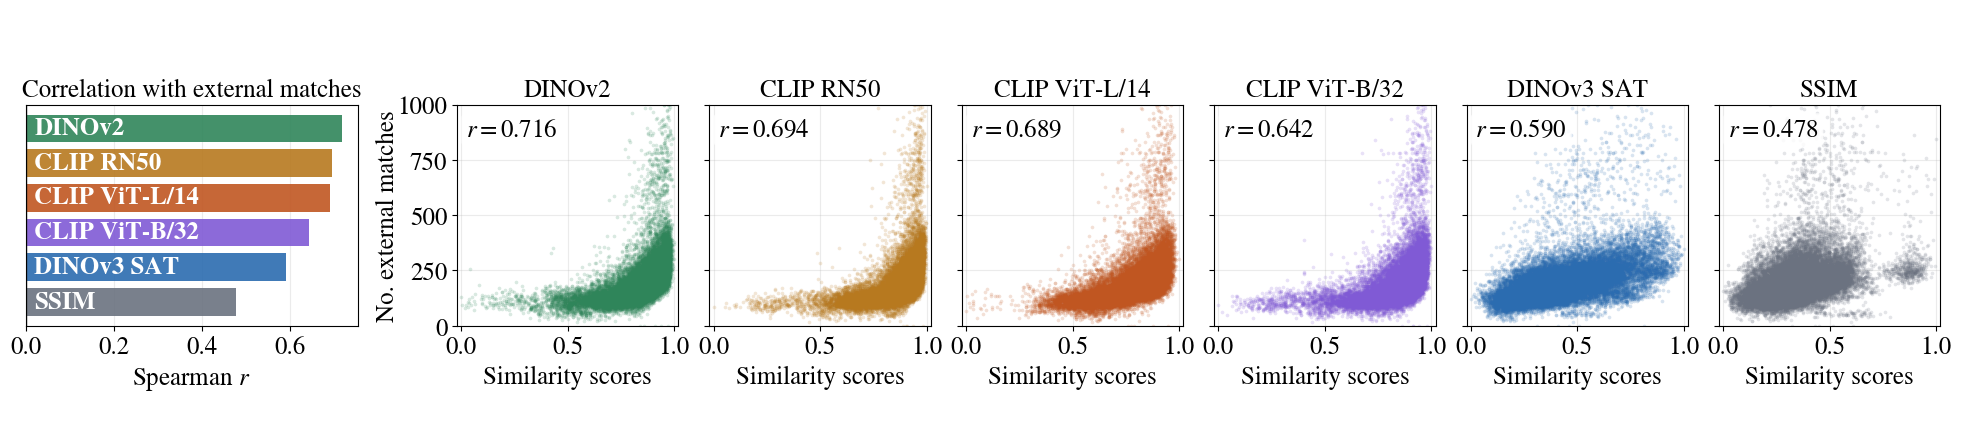

In [29]:
# -----------------------------
# 3. Final 1x7 figure
# -----------------------------

# Re-apply paper typography here so rerunning only this plotting cell is enough.
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble": "",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

method_colors = {
    "ssim": "#6B7280",
    "dinov2": "#2F855A",
    "dinov3_sat": "#2B6CB0",
    "clip_rn50": "#B7791F",
    "clip_vit_b32": "#805AD5",
    "clip_vit_l14": "#C05621",
}

def readable_text_color(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "#111827" if luminance > 0.58 else "white"

bar_corr_df = corr_df.dropna(subset=["spearman"]).copy()
scatter_corr_df = corr_df.dropna(subset=["spearman"]).sort_values(
    "spearman",
    ascending=False,
    na_position="last",
).copy()
ordered_metrics = scatter_corr_df["metric"].tolist()

scatter_width = 0.6
bar_width = 1.5 * scatter_width
bar_scatter_pad = 0.005

fig, axes = plt.subplots(
    1,
    2 + len(ordered_metrics),
    figsize=(19.5, 4.2),
    gridspec_kw={"width_ratios": [bar_width, bar_scatter_pad] + [scatter_width] * len(ordered_metrics)},
    constrained_layout=True,
)

bar_ax = axes[0]
spacer_ax = axes[1]
scatter_axes = axes[2:]
spacer_ax.axis("off")
bar_ax.set_box_aspect(1 / 1.5)
y_positions = np.arange(len(bar_corr_df))
bar_colors = [method_colors.get(metric, "#4C78A8") for metric in bar_corr_df["metric"]]
bars = bar_ax.barh(
    y_positions,
    bar_corr_df["spearman"],
    color=bar_colors,
    alpha=0.9,
)
bar_ax.axvline(0, color="0.25", linewidth=1)
bar_ax.set_yticks(y_positions)
bar_ax.set_yticklabels([])
bar_ax.tick_params(axis="y", length=0)
bar_ax.invert_yaxis()
bar_ax.set_xlabel("Spearman $r$")
bar_ax.set_title("Correlation with external matches")
for bar, label, color in zip(bars, bar_corr_df["metric_label"], bar_colors):
    width = bar.get_width()
    x = 0.02 if width >= 0 else -0.02
    ha = "left" if width >= 0 else "right"
    bar_ax.text(
        x,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha=ha,
        color=readable_text_color(color),
        fontweight="bold",
        fontsize=18,
    )

bar_ax.grid(axis="x", alpha=0.25)
bar_ax.set_axisbelow(True)

x_min, x_max = -0.02, 1.02
y_max = df[target_col].max()
if not np.isfinite(y_max) or y_max <= 0:
    y_max = 1
y_max = float(y_max) * 1.05

for ax, metric in zip(scatter_axes, ordered_metrics):
    valid = df[[metric, target_col]].copy()
    valid[metric] = pd.to_numeric(valid[metric], errors="coerce")
    valid[target_col] = pd.to_numeric(valid[target_col], errors="coerce")
    valid = valid.dropna()
    valid = valid[valid[metric].between(0, 1)]

    display_name = pretty_metric_names.get(metric, metric)
    row = corr_df.loc[corr_df["metric"] == metric].iloc[0]
    color = method_colors.get(metric, "#4C78A8")

    ax.scatter(
        valid[metric],
        valid[target_col],
        alpha=0.18,
        s=7,
        linewidths=0,
        color=color,
    )

    """
    if len(valid) >= 2 and valid[metric].nunique() >= 2 and valid[target_col].nunique() >= 2:
        x = valid[metric].to_numpy()
        y = valid[target_col].to_numpy()
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, color="#E45756", linewidth=1.5)
    """

    ax.set_xlim(x_min, x_max)
    ax.set_xticks([0.0, 0.5, 1.0])
    #ax.set_ylim(0, y_max)
    ax.set_ylim(0, 1000)
    ax.set_box_aspect(1)
    ax.set_title(display_name)
    ax.text(
        0.04,
        0.94,
        f"$r={row['spearman']:.3f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=18,
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
        },
    )
    ax.set_xlabel("Similarity scores")
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)

scatter_axes[0].set_ylabel("No. external matches", labelpad=-2)
for ax in scatter_axes[1:]:
    ax.set_yticklabels([])

"""
fig.suptitle(
    "Descriptor similarity vs SuperPoint+LightGlue match count",
    fontsize=18,
    y=1.04,
)
"""

output_dir = root_dir / "notebooks"
fig.savefig(output_dir / "similarity_study.png", dpi=250, bbox_inches="tight")
fig.savefig(output_dir / "similarity_study.pdf", bbox_inches="tight")
plt.show()
